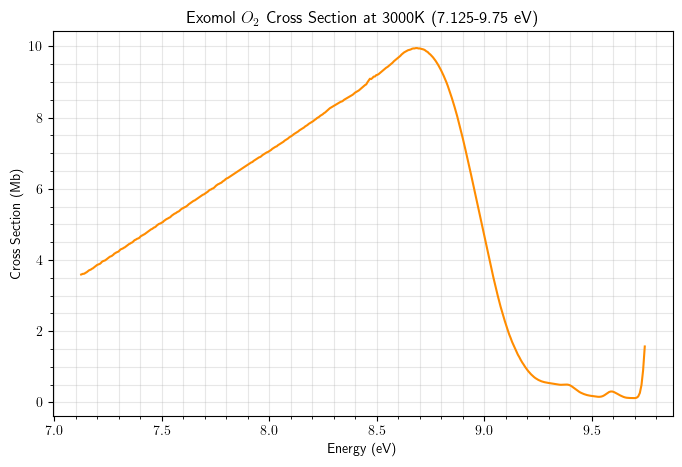

/var/folders/83/vkh47h3s1m5cs8w1z21m4knm0000gn/T/ipykernel_23199/1141121797.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrated_sigma = np.trapz(sigma_mb, energy_ev)


--- Results for 3000K ---
Range: 7.125 - 9.75 eV
Integrated Oscillator Strength (f): 0.125202


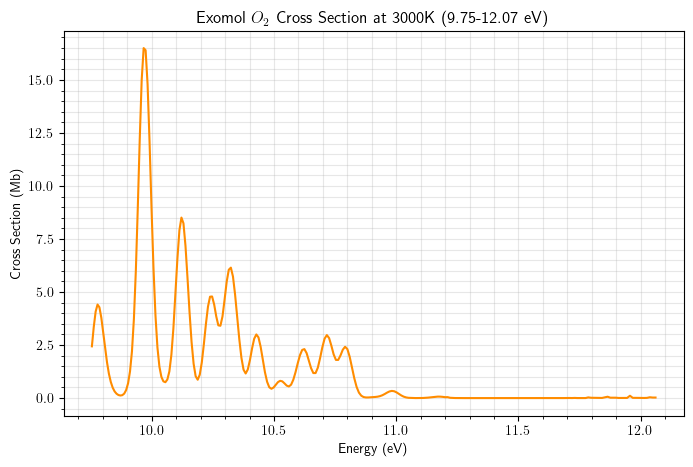

--- Results for 3000K ---
Range: 9.75 - 12.07 eV
Integrated Oscillator Strength (f): 0.030977


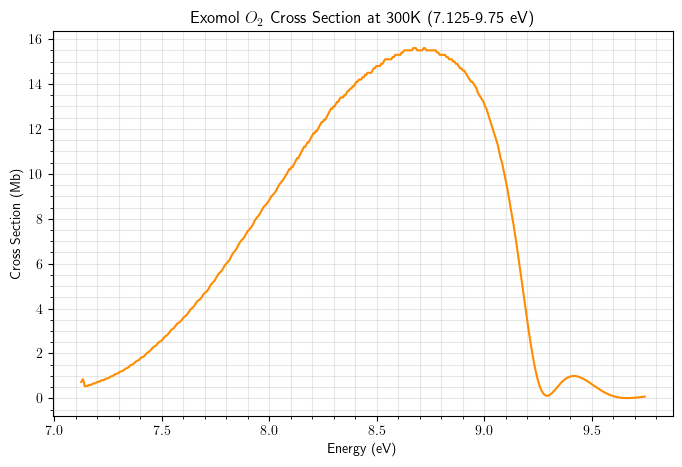

--- Results for 300K ---
Range: 7.125 - 9.75 eV
Integrated Oscillator Strength (f): 0.172685


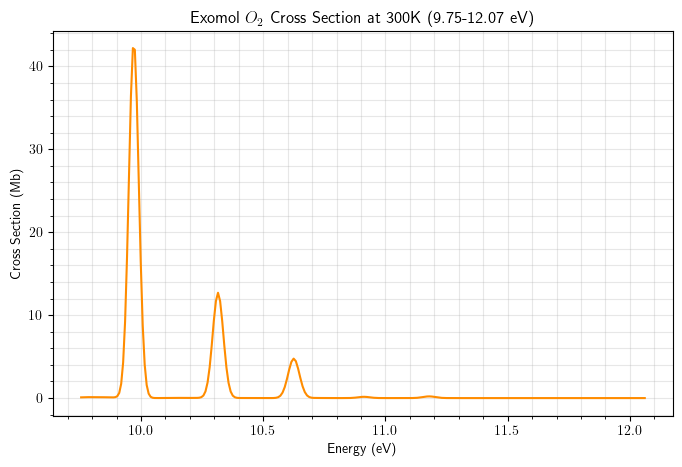

--- Results for 300K ---
Range: 9.75 - 12.07 eV
Integrated Oscillator Strength (f): 0.029255


In [87]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import io

def process_o2_data(temperature, ev_min=7.1, ev_max=9.9):
    url = f"https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__{temperature}__0__0.1.photo"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        
        # Load: Col 0 = wavelength (nm), Col 1 = cross-section (cm^2)
        wl_nm, sigma_cm2 = np.loadtxt(io.StringIO(response.text), unpack=True)

        # 1. Conversions
        # Energy (eV) = 1239.84193 / wavelength (nm)
        energy_ev = 1239.84193 / wl_nm
        # Cross section in Megabarns (Mb): 1 Mb = 1e-18 cm^2
        sigma_mb = sigma_cm2 / 1e-18

        # 2. Clipping (Filter indices where energy is within the specified range)
        mask = (energy_ev >= ev_min) & (energy_ev <= ev_max)
        energy_ev = energy_ev[mask]
        sigma_mb = sigma_mb[mask]
        
        # Sort data by energy (ExoMol data is usually sorted by wavelength)
        idx = np.argsort(energy_ev)
        energy_ev, sigma_mb = energy_ev[idx], sigma_mb[idx]

        # 3. Plotting
        plt.figure(figsize=(8, 5))
        plt.plot(energy_ev, sigma_mb, color='darkorange', lw=1.5)
        # plt.yscale('log')
        plt.xlabel(r'Energy (eV)')
        plt.ylabel(r'Cross Section (Mb)')
        plt.title(rf'Exomol $O_2$ Cross Section at {temperature}K ({ev_min}-{ev_max} eV)')
        plt.grid(True, alpha=0.3, which='both')
        plt.minorticks_on()
        plt.show()

        # 4. Integration & Oscillator Strength
        # Integrated cross section (Mb * eV)
        integrated_sigma = np.trapz(sigma_mb, energy_ev)
        
        # Oscillator Strength (f) = Integrated Sigma / 109.75
        oscillator_strength = integrated_sigma / 109.75
        
        print(f"--- Results for {temperature}K ---")
        print(f"Range: {ev_min} - {ev_max} eV")
        print(f"Integrated Oscillator Strength (f): {oscillator_strength:.6f}")
        
        return energy_ev, sigma_mb, oscillator_strength

    except Exception as e:
        print(f"Error: {e}")

# Execute
T= 3000
energy, sigma, f_value = process_o2_data(temperature=T, ev_min=7.125, ev_max=9.75)
e, s, f = process_o2_data(temperature=T, ev_min=9.75, ev_max=12.07)

T= 300
energy, sigma, f_value = process_o2_data(temperature=T, ev_min=7.125, ev_max=9.75)
e, s, f = process_o2_data(temperature=T, ev_min=9.75, ev_max=12.07)

In [89]:
# --- Fixed Code Structure ---

# 1. Sensing Parameters
sensing_wavelength_nm = 632 
sensing_frequency = 2.9979e8 / (sensing_wavelength_nm * 1e-9) # Hz (Using c = 2.9979e8)

# 2. Convert energy (eV) to Frequency (Hz)
# Logic: E = h*nu => nu = E / h
h_ev_s = 4.135667696e-15 # Planck constant in eV*s
frequencies = energy / h_ev_s # Convert eV to Hz directly

# 3. Handle df/dnu (Oscillator strength density per Hz)
# sigma / 109.75 is (df / d_eV). 
# To get (df / d_Hz), we use: (df / d_eV) * (d_eV / d_Hz) = (df / d_eV) * h_ev_s
df_dnu = (sigma / 109.75) * h_ev_s 

# 4. Compute Integrand
# Note: wavelengths variable is calculated correctly here for reference, 
# but we use 'frequencies' for the integration as requested.
wavelengths = 2.9979e8 / frequencies 

integrand = df_dnu / (frequencies**2 - sensing_frequency**2)
pol_integral = np.trapezoid(integrand, frequencies)

print(f"Polarizability Integral: {pol_integral:.5e}")

Polarizability Integral: 4.40303e-32


In [99]:
# now calculate polarizability contribution for a single discrete feature with known oscillator strength and line position
line_pos_ev = 9.97 # eV
line_pos_freq = (3e8 * 1e9) / (1239.84193 / line_pos_ev) # Hz
S_zero = (189.7-162.0)/1000 # oscillator strength for this line
line_contribution = S_zero / (line_pos_freq**2 - sensing_frequency**2)
line_contribution*1

4.951127394132102e-33

In [91]:
# now calculate polarizability contribution for a single discrete feature with known oscillator strength and line position
# Approximate the continuuum as single line 
line_pos_ev = 8.176 # eV
line_pos_freq = (3e8 * 1e9) / (1239.84193 / line_pos_ev) # Hz
S_zero = (162.0)/1000 # oscillator strength for this line
line_contribution = S_zero / (line_pos_freq**2 - sensing_frequency**2)
line_contribution

4.3917579800001694e-32

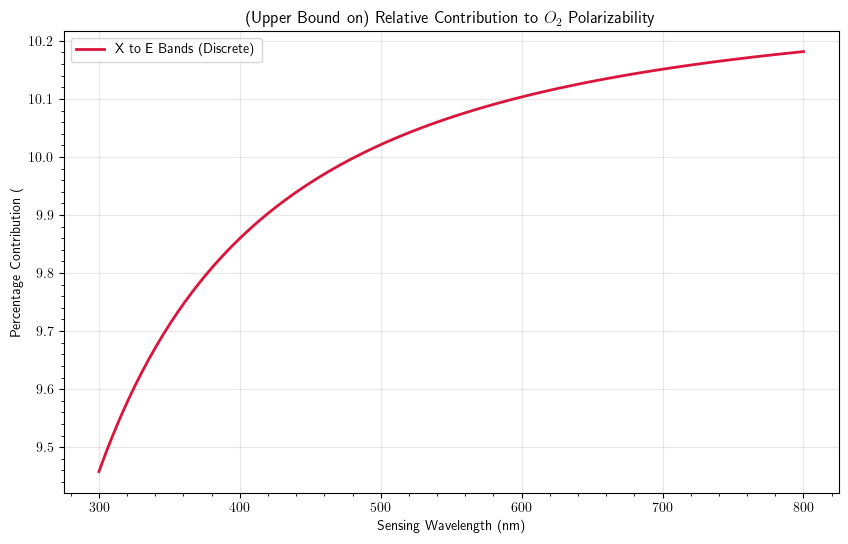

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Sensing Range (Wavelengths in nm)
sensing_wls = np.linspace(300, 800, 100)
h_ev_s = 4.135667696e-15
c = 2.9979e8

# Arrays to store results
continuum_results = []
discrete_results = []

# 2. Loop through sensing wavelengths
for wl_nm in sensing_wls:
    f_sense = c / (wl_nm * 1e-9)
    
    # --- Continuum Contribution (SR Continuum) ---
    # From previous energy/sigma data
    freqs = energy / h_ev_s
    df_dnu = (sigma / 109.75) * h_ev_s
    integrand = df_dnu / (freqs**2 - f_sense**2)
    cont_val = np.trapezoid(integrand, freqs)
    
    # --- Discrete Contribution (X to E bands) ---
    f_line = 9.97 / h_ev_s
    f_osc = (189.7 - 162.0) / 1000
    disc_val = f_osc / (f_line**2 - f_sense**2)
    
    continuum_results.append(cont_val)
    discrete_results.append(disc_val)

# 3. Calculate Percentages
continuum_results = np.array(continuum_results)
discrete_results = np.array(discrete_results)
total = continuum_results + discrete_results

perc_cont = (continuum_results / total) * 100
perc_disc = (discrete_results / total) * 100

# 4. Plotting
plt.figure(figsize=(10, 6))
# plt.plot(sensing_wls, perc_cont, label='SR Continuum (Integral)', lw=2, color='royalblue')
plt.plot(sensing_wls, perc_disc, label='X to E Bands (Discrete)', lw=2, color='crimson')
plt.tick_params(axis='both', which='minor', labelsize=10)
plt.xlabel('Sensing Wavelength (nm)')
plt.ylabel('Percentage Contribution (%)')
plt.title('(Upper Bound on) Relative Contribution to $O_2$ Polarizability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.minorticks_on()
# plt.ylim(0, 100)
plt.show()

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator

# Use LaTeX for all text to match thesis plotting style.
# Removed mpl.use("pgf") from the top so plt.show() actually works for previewing.
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
})

# ─────────────────────────────────────────────────────────────────
# 1. Hardcoded Data
# ─────────────────────────────────────────────────────────────────

# --- X state PEC ---
X_data = [
    [0.9, 65911.8541], [0.95, 39807.05865], [1.0, 22411.47015], [1.05, 11227.90205],
    [1.1, 4571.005825], [1.125, 2524.181975], [1.15, 1152.24375], [1.175, 352.47685],
    [1.207, 0.0], [1.25, 485.698175], [1.3, 2009.293625], [1.35, 4265.27715],
    [1.4, 6987.864525], [1.5, 13078.9542], [1.6, 19254.9807], [1.7, 24997.3246],
    [1.8, 29973.04233], [2.0, 37146.5827], [2.2, 40379.8884], [2.4, 41395.39923],
    [2.6, 41701.56685], [2.8, 41831.27658], [3.0, 41864.4173], [6.0, 42021.5614]
]
X_r, X_energy = np.array(list(zip(*X_data)))

# --- B state PEC ---
B_data = [
    [0.89816821, 111382.7063], [0.924758716, 95333.85858], [0.962773291, 86612.17254],
    [1.014772503, 77894.42584], [1.050324995, 76214.29978], [1.113748277, 74823.71479],
    [1.155702186, 74835.53279], [1.198148513, 73439.0388], [1.219617885, 72036.63581],
    [1.248571991, 69227.89049], [1.27053378, 66417.1755], [1.292298602, 64169.78531],
    [1.301324503, 60154.4774], [1.317880795, 59329.11028], [1.324503311, 58198.96343],
    [1.337748344, 57243.01756], [1.350993377, 56156.63691], [1.370860927, 55287.9355],
    [1.38410596, 54418.94616], [1.394039735, 53593.2911], [1.410596026, 53072.27181],
    [1.437086093, 52160.38007], [1.456953642, 51552.54823], [1.476821192, 51031.67291],
    [1.506622517, 50554.70775], [1.533112583, 50294.98992], [1.569536424, 49861.79096],
    [1.625827815, 49907.71667], [1.668874172, 50083.5013], [1.708609272, 50302.62021],
    [1.745033113, 50608.55168], [1.784768212, 51262.45321], [1.847682119, 51873.88425],
    [1.887417219, 52484.30752], [1.927152318, 52920.81774], [1.963576159, 53444.14051],
    [2.009933775, 53967.89519], [2.049668874, 54404.40541], [2.105960265, 54928.592],
    [2.162251656, 55496.25684], [2.221854305, 55933.63087], [2.28807947, 56240.85805],
    [2.377483444, 56592.57126], [2.450331126, 56856.60812], [2.523178808, 57033.68845],
    [2.582781457, 57253.67118], [2.668874172, 57474.80564], [2.728476821, 57477.39706],
    [2.798013245, 57567.37691], [2.867549669, 57613.87849], [2.937086093, 57703.85834],
    [2.988410596, 57727.82897], [3.0, 57728.82897], [3.8, 57728.82897]
]

B3Sigma_minus_subset = [
    (1.1, 100000.0), (1.199608611, 73661.65252), (1.223091977, 70244.79602),
    (1.238747554, 67055.72996), (1.26223092, 64550.0352), (1.293542074, 61588.75958),
    (1.324853229, 58855.27438), (1.363992172, 56349.57962), (1.410958904, 54071.6753),
    (1.457925636, 51565.98053), (1.544031311, 50199.23794), (1.6042, 49793.28),
    (1.700587084, 50199.23794), (1.818003914, 51110.39967), (1.927592955, 52477.14227),
    (1.998043053, 53616.09443), (2.13111546, 54755.04659), (2.272015656, 56121.78919),
    (2.412915851, 57032.95092), (2.53816047, 57146.84614), (2.647749511, 57488.53179),
    (2.741682975, 57488.53179), (2.866927593, 57716.32222), (2.984344423, 57488.53179),
    (3.093933464, 57488.53179), (3.266144814, 57488.53179), (3.383561644, 57488.53179),
    (3.532289628, 57602.427), (3.649706458, 57716.32222), (3.798434442, 57716.32222),
    (3.939334638, 57830.21744),
]

B_r, B_energy = np.array(list(zip(*B_data)))
B_r_2, B3Sigma_minus_subset = np.array(list(zip(*B3Sigma_minus_subset)))

# --- TDM Qin 2023 ---
TDM_Qin_data = [
    [0.975087413, 0.323927849], [0.988199301, 0.423412488], [1.001311189, 0.499200444],
    [1.014423077, 0.58920641], [1.024912587, 0.683959997], [1.035402098, 0.78582259],
    [1.045891608, 0.882945846], [1.061625874, 0.968204189], [1.066870629, 1.034538329],
    [1.074737762, 1.110342856], [1.083916084, 1.195621914], [1.090472028, 1.27616992],
    [1.100961538, 1.347226825], [1.111451049, 1.441980413], [1.121940559, 1.522515991],
    [1.13243007, 1.622008915], [1.140297203, 1.712031452], [1.145541958, 1.783104928],
    [1.156031469, 1.806768468], [1.171765734, 1.778282736], [1.184877622, 1.754544626],
    [1.213723776, 1.754453485], [1.238636364, 1.721199417], [1.258304196, 1.692701256],
    [1.280594406, 1.647607132], [1.308129371, 1.588278428], [1.357954545, 1.483855599],
    [1.410402098, 1.384163822], [1.460227273, 1.289219667], [1.516608392, 1.191885129],
    [1.571678322, 1.101663739], [1.61756993, 1.018580353], [1.66215035, 0.947349451],
    [1.698863636, 0.890361416], [1.730332168, 0.833389951], [1.767045455, 0.771662579],
    [1.810314685, 0.688587479], [1.853583916, 0.610251715], [1.90472028, 0.515303417],
    [1.941433566, 0.455945713], [1.995192308, 0.368098134], [2.045017483, 0.287371988],
    [2.118444056, 0.199462268], [2.189248252, 0.135257515], [2.252185315, 0.09714397],
    [2.294143357, 0.0], [2.317744755, 0.0], [2.336101399, 0.0], [2.354458042, 0.0],
    [2.401660839, 0.0], [2.438374126, 0.0], [2.472465035, 0.0], [2.538024476, 0.0],
    [2.55, 0.0], [2.58, 0.0], [3.0, 0.0]
]
TDM_Qin_r, TDM_Qin_mu = np.array(list(zip(*TDM_Qin_data)))

# --- TDM Friedman 1990 ---
TDM_Friedman_data = [
    [0.751968504, 0.676886792], [0.775590551, 0.676886792], [0.796587927, 0.676886792],
    [0.833333333, 0.676886792], [0.898950131, 0.676886792], [0.959317585, 0.676886792],
    [0.927821522, 0.676886792], [0.988188976, 0.686320755], [1.011811024, 0.70990566],
    [1.032808399, 0.752358491], [1.043307087, 0.79009434], [1.059055118, 0.837264151],
    [1.066929134, 0.875], [1.07480315, 0.941037736], [1.085301837, 0.988207547],
    [1.093175853, 1.058962264], [1.098425197, 1.110849057], [1.103674541, 1.214622642],
    [1.106299213, 1.271226415], [1.11023622, 1.323113208], [1.111548556, 1.370283019],
    [1.114173228, 1.424528302], [1.1167979, 1.488207547], [1.118110236, 1.533018868],
    [1.119422572, 1.629716981], [1.122047244, 1.738207547], [1.12335958, 1.841981132],
    [1.124671916, 1.891509434], [1.125984252, 1.943396226], [1.127296588, 1.995283019],
    [1.12992126, 2.101415094], [1.132545932, 2.143867925], [1.135170604, 2.240566038],
    [1.137795276, 2.299528302], [1.143044619, 2.337264151], [1.161417323, 2.375],
    [1.174540682, 2.351415094], [1.187664042, 2.323113208], [1.206036745, 2.275943396],
    [1.217847769, 2.228773585], [1.234908136, 2.195754717], [1.25328084, 2.148584906],
    [1.266404199, 2.106132075], [1.282152231, 2.068396226], [1.297900262, 2.035377358],
    [1.311023622, 1.997641509], [1.329396325, 1.95990566], [1.347769029, 1.91745283],
    [1.360892388, 1.884433962], [1.379265092, 1.841981132], [1.397637795, 1.804245283],
    [1.416010499, 1.771226415], [1.426509186, 1.747641509], [1.442257218, 1.728773585],
    [1.452755906, 1.695754717], [1.465879265, 1.672169811], [1.484251969, 1.643867925],
    [1.5, 1.610849057], [1.520997375, 1.573113208], [1.549868766, 1.516509434],
    [1.602362205, 1.431603774], [1.667979003, 1.318396226], [1.715223097, 1.233490566],
    [1.893700787, 0.950471698], [1.796587927, 1.091981132], [1.998687664, 0.827830189],
    [2.106299213, 0.705188679], [2.18503937, 0.634433962], [2.245406824, 0.577830189],
    [2.326771654, 0.516509434], [2.405511811, 0.464622642], [2.494750656, 0.410377358],
    [2.536745407, 0.379716981], [2.589238845, 0.356132075], [2.654855643, 0.327830189],
    [2.723097113, 0.294811321], [2.780839895, 0.271226415], [2.817585302, 0.257075472],
    [2.859580052, 0.242924528], [2.901574803, 0.233490566], [2.954068241, 0.214622642],
    [2.998687664, 0.200471698]
]
TDM_Friedman_r, TDM_Friedman_mu = np.array(list(zip(*TDM_Friedman_data)))

# Find minima (equilibrium points) for X and B PECs.
x_min_idx = np.argmin(X_energy)
b_min_idx = np.argmin(B_energy)
X_re, X_emin = X_r[x_min_idx], X_energy[x_min_idx]
B_re, B_emin = B_r[b_min_idx], B_energy[b_min_idx]

# ─────────────────────────────────────────────────────────────────
# 2. Plotting
# ─────────────────────────────────────────────────────────────────

# --- Setup Figure: 2 rows, 1 column (stacked) ---
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 10)  # Width, Height in inches
)

# --- Subplot 1: Potential Energy Curves (PECs) ---
ax1.plot(X_r, X_energy, label=r'X $^3\Sigma_g^-$', color='blue', linewidth=2, linestyle='--')
ax1.plot(B_r, B_energy, label=r'B $^3\Sigma_g^-$', color='red', linewidth=2, linestyle='--')
ax1.plot(B_r_2, B3Sigma_minus_subset, label=r'B $^3\Sigma_g^-$ (subset)', color='orange', linewidth=2, linestyle='--')

# Mark minima with large red dots.
ax1.scatter([X_re, B_re], [X_emin, B_emin], color='red', s=120, zorder=6, label='Equilibrium points')
ax1.annotate(
    fr'$r_e$(X) = {X_re:.3f}\,\mathrm{{\AA}}$',
    xy=(X_re, X_emin),
    xytext=(X_re + 0.10, X_emin + 9000),
    color='red',
    fontsize=12,
    arrowprops=dict(arrowstyle='->', color='red', lw=1.0),
)
ax1.annotate(
    fr'$r_e$(B) = {B_re:.3f}\,\mathrm{{\AA}}$',
    xy=(B_re, B_emin),
    xytext=(B_re + 0.10, B_emin + 9000),
    color='red',
    fontsize=12,
    arrowprops=dict(arrowstyle='->', color='red', lw=1.0),
)

# --- Subplot 2: Transition Dipole Moments (TDMs) ---
ax2.plot(TDM_Qin_r, TDM_Qin_mu, label='Qin et al. (2023)', color='purple', linestyle='--', linewidth=2)
ax2.plot(TDM_Friedman_r, TDM_Friedman_mu, label='Friedman (1990)', color='green', linestyle='--', linewidth=2)

# ─────────────────────────────────────────────────────────────────
# 3. Styling (using our template)
# ─────────────────────────────────────────────────────────────────

# --- Style ax1 (PECs) ---
# Added 'r' before the string to make it a raw string so \AA processes properly
ax1.set_xlabel(r'Internuclear Distance [\AA]', fontsize=14)
ax1.set_ylabel(r'Energy [cm$^{-1}$]', fontsize=14)
ax1.legend(loc='upper right', fontsize=11)
ax1.tick_params(which='major', direction='in', length=6, top=True, right=True, labelsize=12)
ax1.tick_params(which='minor', direction='in', length=4, top=True, right=True)
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.set_xlim(0.9, 3.6)
ax1.set_ylim(0, 120000)

# --- Style ax2 (TDMs) ---
# Added 'r' before the string to make it a raw string so \AA processes properly
ax2.set_xlabel(r'Internuclear Distance [\AA]', fontsize=14)
ax2.set_ylabel(r'Transition Dipole Moment ($\mu$) [Debye]', fontsize=14)
ax2.legend(loc='best', fontsize=12)
ax2.tick_params(which='major', direction='in', length=6, top=True, right=True, labelsize=12)
ax2.tick_params(which='minor', direction='in', length=4, top=True, right=True)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.set_xlim(0.9, 3.6)
ax2.set_ylim(0, 2.5)

# --- Final Layout Adjustment ---
# plt.tight_layout()

# Uncomment the line below to export directly using the pgf settings defined at the top
# plt.savefig("O2_Schumann_Runge_PEC_TDM_comparison.pgf") 

plt.show()

ValueError: Error measuring {\rmfamily\fontsize{12.000000}{14.400000}\selectfont\catcode`\^=\active\def^{\ifmmode\sp\else\^{}\fi}\catcode`\%=\active\def%{\%}$r_e$(X) = 1.207\,\mathrm{\AA}$}
LaTeX Output:

! LaTeX Error: \mathrm allowed only in math mode.

See the LaTeX manual or LaTeX Companion for explanation.
Type  H <return>  for immediate help.
 ...                                              
                                                  
<*> ...e\def%{\%}$r_e$(X) = 1.207\,\mathrm{\AA}$}}
                                                  \typeout{\the\wd0,\the\ht0...

!  ==> Fatal error occurred, no output PDF file produced!
Transcript written on texput.log.
